### Setup

In [ ]:
# imports
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 as transforms


# config
train_batch_size = 64
test_batch_size = 64
learning_rate = 1e-3
epochs = 10


# training and test data
image_transform = transforms.Compose([
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True)
])

training_data = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = image_transform
)

test_data = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = image_transform
)

training_loader = DataLoader(training_data, batch_size=train_batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_batch_size, shuffle=True)


### Data Examples

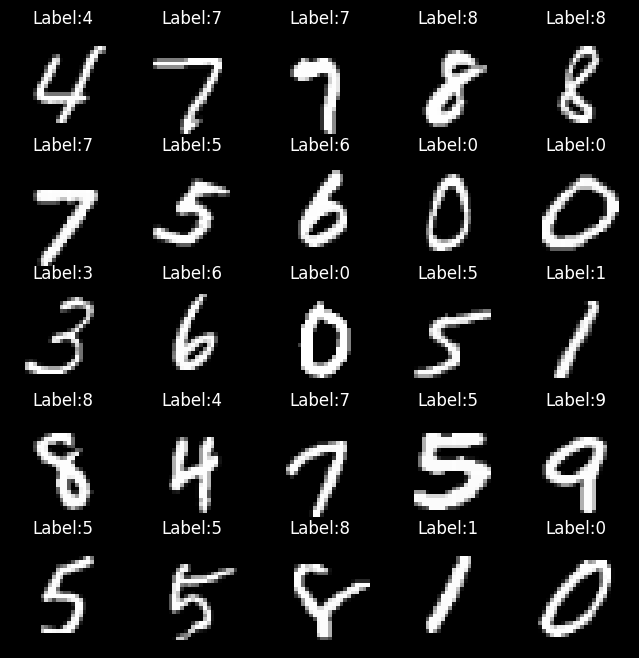

In [ ]:
# examples
plt.style.use('dark_background')
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    rand_index = torch.randint(0, len(training_data)-25, (1,)).item()
    image, label = training_data[rand_index+i]
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

### Model

In [ ]:
# model
class ConvNeuralNetwork(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.convolution = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
        nn.LogSoftmax(dim=1)
    )

  def forward(self, x):
    x = self.convolution(x)
    output = self.classifier(x)

    return output


def train(dataloader, model, loss_fn, optimizer):
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    output = model(X)
    loss = loss_fn(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{len(dataloader.dataset):>5d}]")


def test(dataloader, model, loss_fn):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
      for X, y in dataloader:
        output = model(X)
        test_loss += loss_fn(output, y).item()
        pred = output.argmax(1)
        correct += (pred == y).type(torch.float).sum().item()
    test_loss /= len(dataloader)
    correct /= len(dataloader.dataset)

    print(f"\n Test \n Avg loss: {test_loss:>8f}, Accuracy: {(100*correct):>0.1f}%")


model = ConvNeuralNetwork()

loss_fn = nn.NLLLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


test(test_loader, model, loss_fn)

for epoch in range(epochs):
  print(f"Eppoch {epoch+1}/{epochs}")
  train(training_loader, model, loss_fn, optimizer)
  test(test_loader, model, loss_fn)


 Test 
 Avg loss: 2.304850, Accuracy: 12.2% 


Epoch 0
loss: 2.301767  [    0/60000]
loss: 2.293451  [ 6400/60000]
loss: 2.299833  [12800/60000]
loss: 2.293774  [19200/60000]
loss: 2.262005  [25600/60000]
loss: 2.283338  [32000/60000]
loss: 2.265988  [38400/60000]
loss: 2.275221  [44800/60000]
loss: 2.267575  [51200/60000]
loss: 2.249689  [57600/60000]

 Test 
 Avg loss: 2.254804, Accuracy: 37.3% 


Epoch 1
loss: 2.254310  [    0/60000]
loss: 2.249143  [ 6400/60000]
loss: 2.251335  [12800/60000]
loss: 2.232435  [19200/60000]
loss: 2.219959  [25600/60000]
loss: 2.209018  [32000/60000]
loss: 2.178509  [38400/60000]
loss: 2.180368  [44800/60000]
loss: 2.153764  [51200/60000]
loss: 2.128348  [57600/60000]

 Test 
 Avg loss: 2.130157, Accuracy: 59.3% 


Epoch 2
loss: 2.148255  [    0/60000]
loss: 2.116724  [ 6400/60000]
loss: 2.042999  [12800/60000]
loss: 2.041849  [19200/60000]
loss: 2.017986  [25600/60000]
loss: 2.011648  [32000/60000]
loss: 1.868535  [38400/60000]
loss: 1.871007  [44800

### Prediction Example

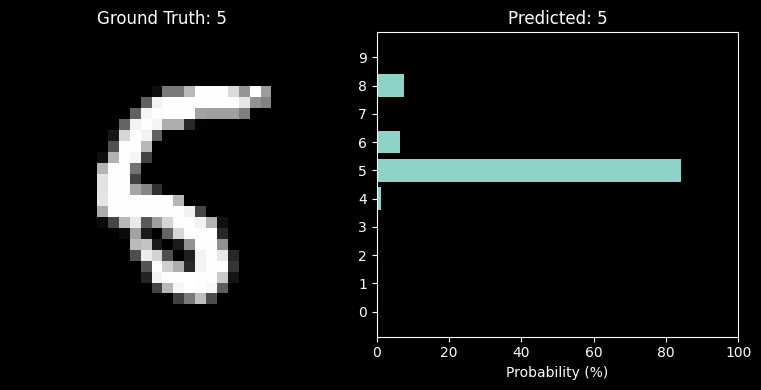

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
rand_index = torch.randint(0, len(training_data), (1,)).item()
image, label = training_data[rand_index]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Ground Truth: {label}")
plt.axis("off")

model.eval()
with torch.no_grad():
  output = model(image.unsqueeze(0))

probabilities = torch.exp(output)
pred = torch.argmax(probabilities)

plt.subplot(1, 2, 2)
class_labels = [str(i) for i in range(10)]
plt.barh(class_labels, probabilities.squeeze().numpy() * 100)
plt.title(f"Predicted: {pred.item()}")
plt.xlabel("Probability (%)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()